## Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import StandardScaler

In [2]:
import warnings

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

In [3]:
df = pd.read_csv(r"C:\Users\shiri\OneDrive\Documents\Python\ml-projects\exchange-rates-forecasting\data\raw\Exchange_rate_report.csv")

## Basic Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6323 entries, 0 to 6322
Data columns (total 8 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Date                                            6323 non-null   object 
 1   Australian dollar   (AUD)                       6040 non-null   float64
 2   Euro   (EUR)                                    6230 non-null   float64
 3   Indian rupee   (INR)                            5804 non-null   float64
 4   Japanese yen   (JPY)                            5980 non-null   float64
 5   U.A.E. dirham   (AED)                           5939 non-null   float64
 6   U.K. pound   (GBP)                              6205 non-null   float64
 7   U.S. dollar   (USD)                             6323 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 395.3+ KB


In [5]:
df.shape

(6323, 8)

In [6]:
df.columns

Index(['Date', 'Australian dollar   (AUD)                     ',
       'Euro   (EUR)                     ',
       'Indian rupee   (INR)                     ',
       'Japanese yen   (JPY)                     ',
       'U.A.E. dirham   (AED)                     ',
       'U.K. pound   (GBP)                     ',
       'U.S. dollar   (USD)                     '],
      dtype='object')

In [7]:
df.nunique()

Date                                              6323
Australian dollar   (AUD)                         3259
Euro   (EUR)                                      3659
Indian rupee   (INR)                              3697
Japanese yen   (JPY)                              2914
U.A.E. dirham   (AED)                                2
U.K. pound   (GBP)                                4396
U.S. dollar   (USD)                                  1
dtype: int64

In [8]:
df.describe()

,Australian dollar (AUD),Euro (EUR),Indian rupee (INR),Japanese yen (JPY),U.A.E. dirham (AED),U.K. pound (GBP),U.S. dollar (USD)
count,6040.000000,6230.000000,5804.000000,5980.000000,5939.000000,6205.000000,6323.0
mean,0.761976,1.189575,57.589529,110.806595,3.672500,1.530293,1.0
std,0.139127,0.157474,13.542462,16.650858,0.000032,0.223917,0.0
min,0.483300,0.825200,39.270000,75.860000,3.672500,1.065400,1.0
25%,0.673575,1.088825,45.800000,103.200000,3.672500,1.323600,1.0
50%,0.746000,1.181200,51.815000,109.955000,3.672500,1.525400,1.0
75%,0.846650,1.308000,68.606050,118.900000,3.672500,1.646800,1.0
max,1.105500,1.599000,85.088000,161.640000,3.675000,2.102000,1.0


## Data Cleaning

### Duplicates

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Missing values

In [10]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values

Australian dollar   (AUD)                         283
Euro   (EUR)                                       93
Indian rupee   (INR)                              519
Japanese yen   (JPY)                              343
U.A.E. dirham   (AED)                             384
U.K. pound   (GBP)                                118
dtype: int64

In [11]:
# Handle missing values
# Forward-fill, then backward-fill for any remaining NaNs
df = df.ffill().bfill()

### Data Type

In [12]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

### Clean names

In [13]:
# Clean column names: lowercase, snake_case, remove special characters
df = df.clean_names(case_type='snake')

### Outliers

In [14]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

In [15]:
for col in df.columns:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

australian_dollar_aud_: 2 outliers
euro_eur_: 0 outliers
indian_rupee_inr_: 0 outliers
japanese_yen_jpy_: 657 outliers
u_a_e_dirham_aed_: 1 outliers
u_k_pound_gbp_: 0 outliers
u_s_dollar_usd_: 0 outliers


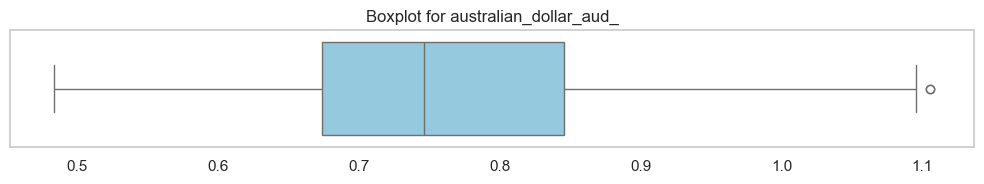

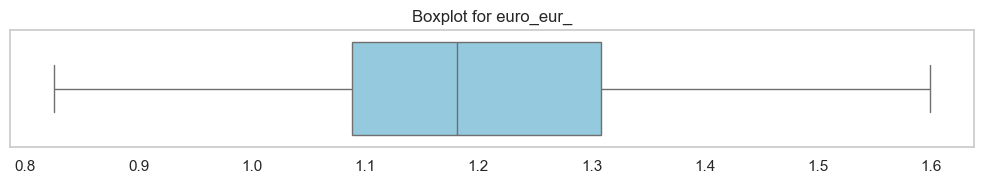

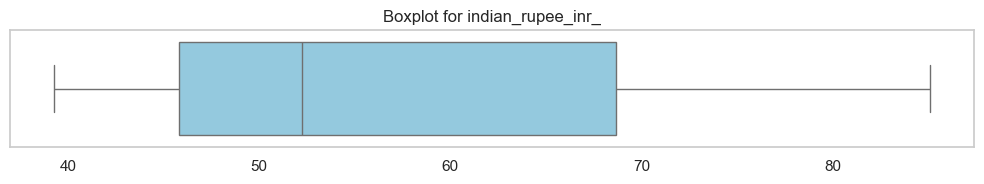

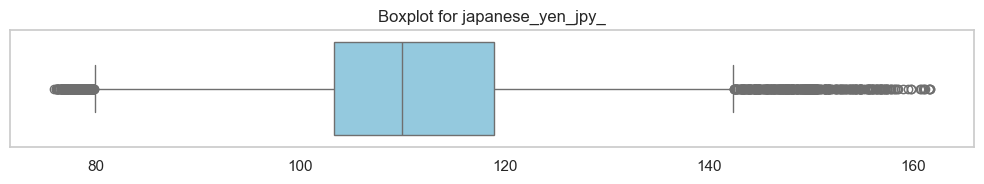

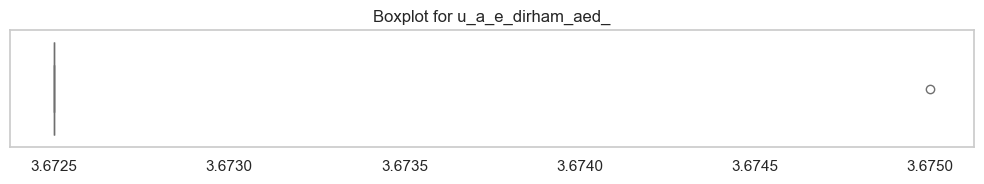

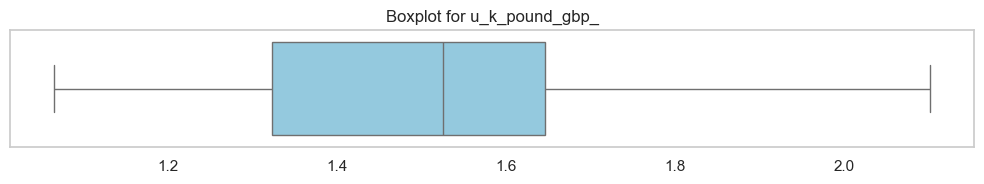

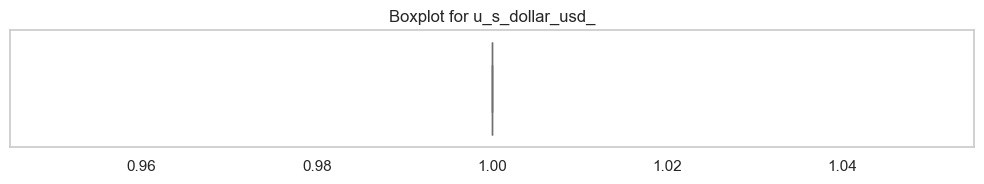

In [16]:
# Set global style
sns.set(style="whitegrid")

# Plot boxplots for all numeric columns
def plot_all_boxplots(df):
    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'Boxplot for {col}', fontsize=12)
        plt.xlabel('')
        plt.grid(False)
        plt.tight_layout()
        plt.show()

# Call the function
plot_all_boxplots(df)

The Japanese Yen (JPY) values have a naturally higher magnitude range (around 75 to 160+), which is much larger than other currency values. Due to this larger scale and slight skewness in the data distribution, many values fall just outside the typical IQR whisker bounds (1.5 × IQR). This causes the boxplot to mark them as outliers even though they are part of the natural variability of the data and not necessarily erroneous or extreme values. Therefore, these ‘outliers’ should be interpreted cautiously and not automatically removed.


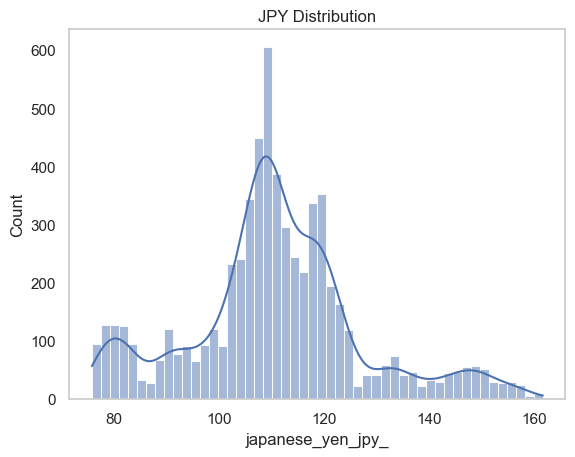

In [17]:
sns.histplot(df['japanese_yen_jpy_'], kde=True, bins=50)
plt.title('JPY Distribution')
plt.grid(False)
plt.show()

In [18]:
outliers = detect_outliers_iqr(df, 'u_a_e_dirham_aed_')
outliers

,australian_dollar_aud_,euro_eur_,indian_rupee_inr_,japanese_yen_jpy_,u_a_e_dirham_aed_,u_k_pound_gbp_,u_s_dollar_usd_
Date,,,,,,,
2008-04-08,0.9272,1.5694,40.02,102.3,3.675,1.9709,1


In [22]:
# Column to apply IQR capping
cap_column = 'japanese_yen_jpy_'
Q1 = df[cap_column].quantile(0.25)
Q3 = df[cap_column].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping directly in df
df[cap_column] = df[cap_column].clip(lower=lower_bound, upper=upper_bound)

print("Transformations applied successfully.")

Transformations applied successfully.


In [23]:
# Columns to apply log transform
log_columns = [
    'australian_dollar_aud_', 
    'indian_rupee_inr_', 
    'u_k_pound_gbp_'
]

# Apply log1p directly to df
for col in log_columns:
    if (df[col] > 0).all():  # Ensure all values are positive
        df[col] = np.log1p(df[col])
    else:
        print(f"Skipped log transform for {col} due to non-positive values.")

In [25]:
df.rename(columns={
    'australian_dollar_aud_': 'AUD',
    'euro_eur_': 'EUR',
    'indian_rupee_inr_': 'INR',
    'japanese_yen_jpy_': 'JPY',
    'u_a_e_dirham_aed_': 'AED',
    'u_k_pound_gbp_': 'GBP',
    'u_s_dollar_usd_': 'USD'
}, inplace=True)


In [26]:
for col in df.columns:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

AUD: 0 outliers
EUR: 0 outliers
INR: 0 outliers
JPY: 0 outliers
AED: 0 outliers
GBP: 0 outliers
USD: 0 outliers


## Exploratory Data Analysis

### Relationships Between Variables

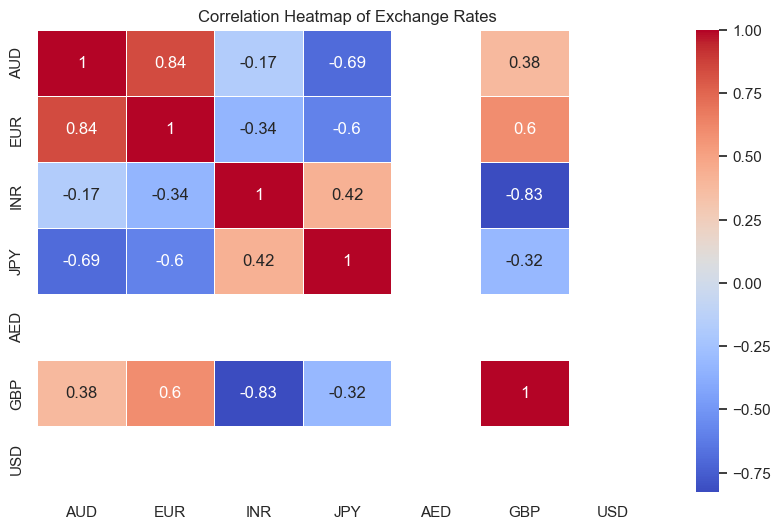

In [27]:
# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Exchange Rates')
plt.grid(False)
plt.show()

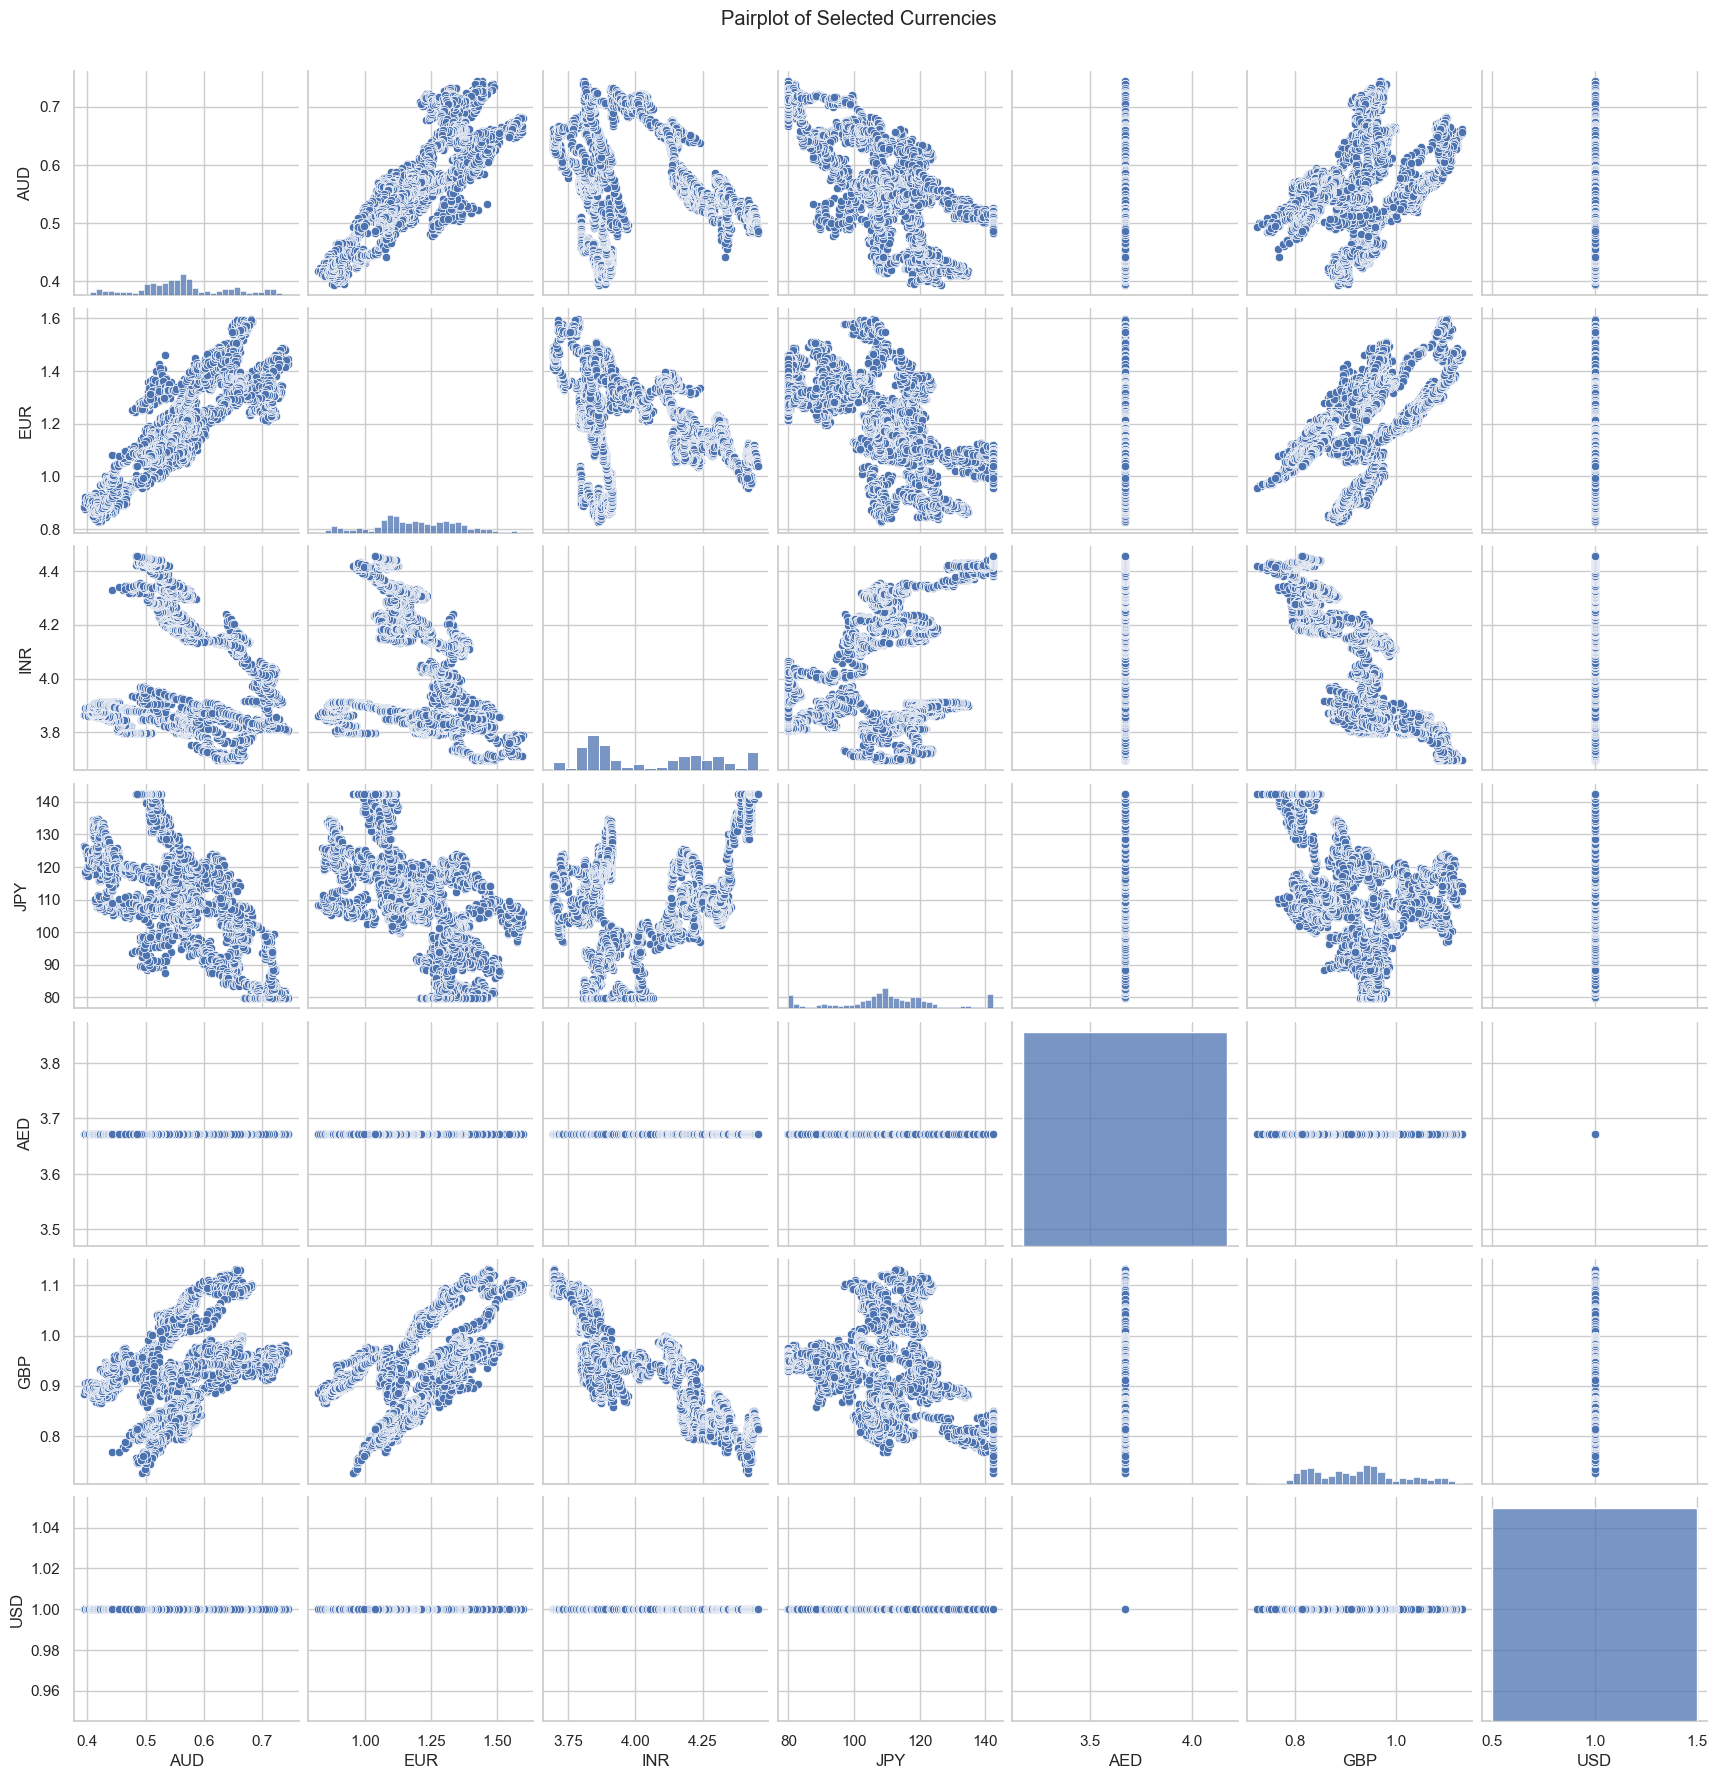

In [28]:
# Plot pairplot 
sns.pairplot(df)
plt.suptitle('Pairplot of Selected Currencies', y=1.02)
plt.grid(False)
plt.show()

### Time Series Analysis

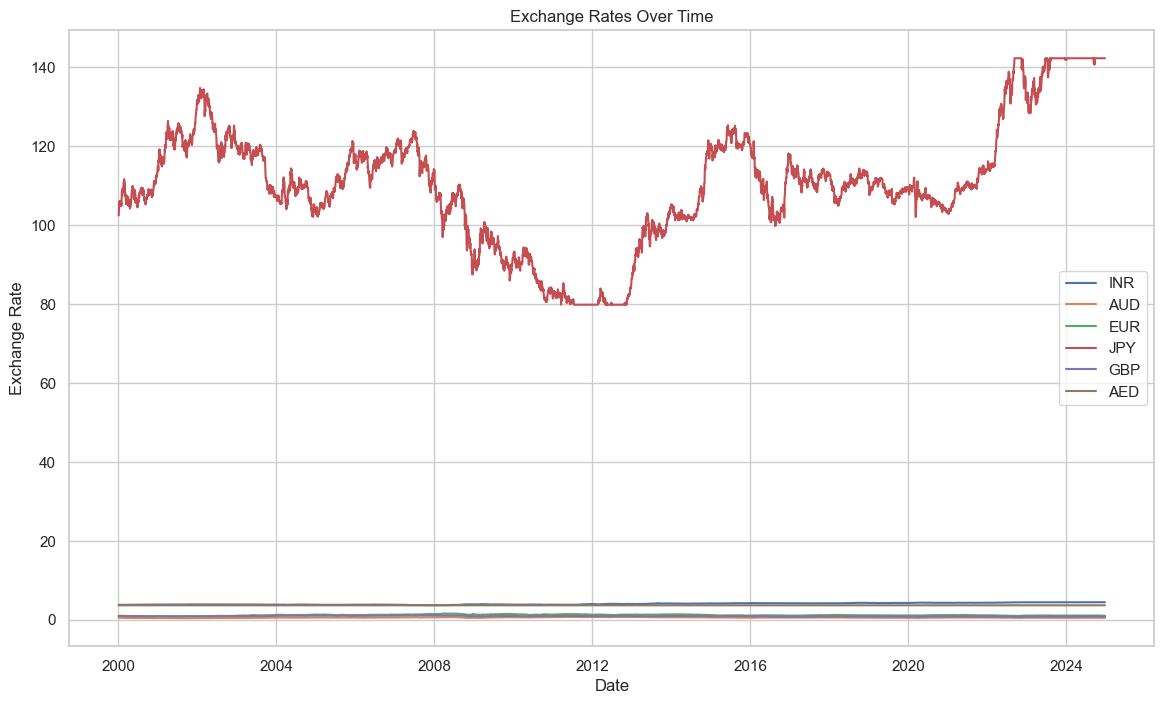

In [37]:
currencies = ['INR', 'AUD', 'EUR', 'JPY', 'GBP', 'AED']  
        
plt.figure(figsize=(14, 8))
for currency in currencies:
    plt.plot(df[currency], label=currency)
plt.title('Exchange Rates Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
for currency in currencies:
    if df[currency].nunique() == 1:
        print(f"{currency} is constant, skipping ADF test.")
        continue
    result = adfuller(df[currency])
    print(f'ADF Statistic for {currency}: {result[0]}')
    print(f'p-value for {currency}: {result[1]}')
    if result[1] <= 0.05:
        print(f'{currency} is stationary.')
    else:
        print(f'{currency} is non-stationary.')

ADF Statistic for INR: -0.07205559990141505
p-value for INR: 0.9521517468802545
INR is non-stationary.
ADF Statistic for AUD: -1.5460690223506413
p-value for AUD: 0.5106111691976064
AUD is non-stationary.
ADF Statistic for EUR: -1.8442783093877917
p-value for EUR: 0.3587107051149687
EUR is non-stationary.
ADF Statistic for JPY: -0.9719436754707155
p-value for JPY: 0.7633591896059639
JPY is non-stationary.
ADF Statistic for GBP: -1.2437574716128523
p-value for GBP: 0.6544949743048749
GBP is non-stationary.
AED is constant, skipping ADF test.


To model time series data using Recurrent Neural Networks (RNNs) effectively, we aim to make the data **stationary**—meaning the statistical properties like mean and variance remain constant over time.

Most currency exchange rates exhibit **non-stationary behavior** due to trends, seasonal effects, or long-term drifts. Feeding non-stationary data into an RNN can:

- Lead to unstable or biased model training,
- Violate assumptions required for effective time series learning,
- Reduce prediction accuracy.

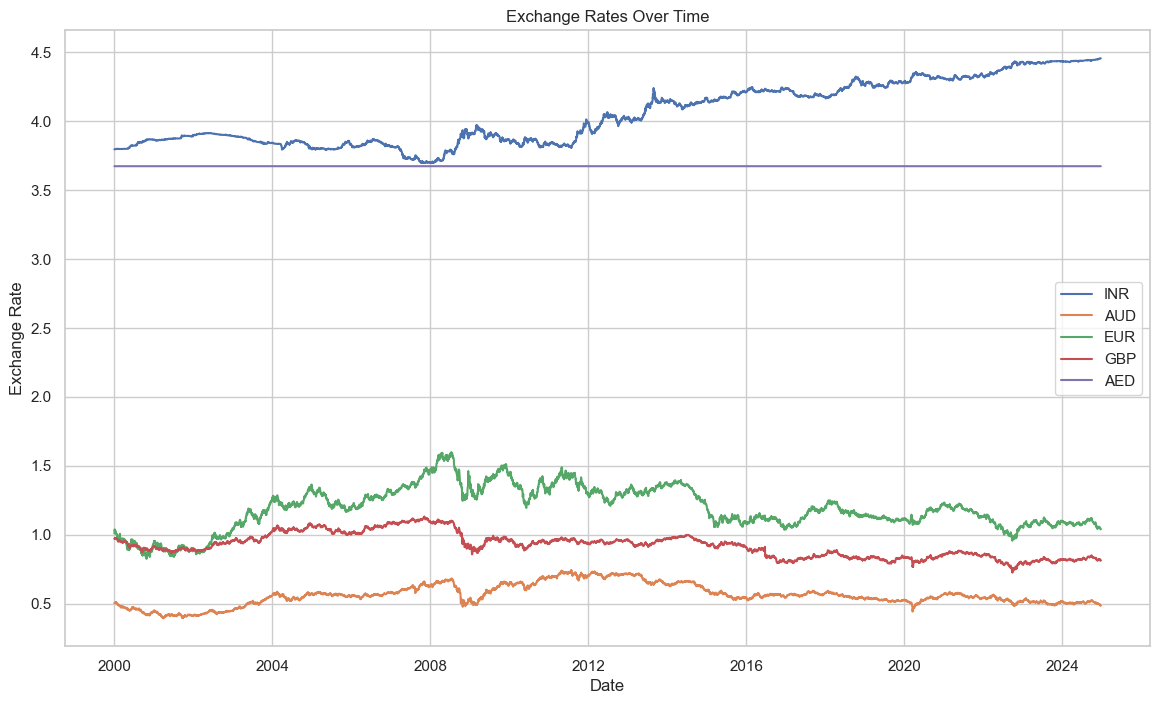

In [39]:
currencies = ['INR', 'AUD', 'EUR', 'GBP', 'AED']  
        
plt.figure(figsize=(14, 8))
for currency in currencies:
    plt.plot(df[currency], label=currency)
plt.title('Exchange Rates Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

Decomposition for INR


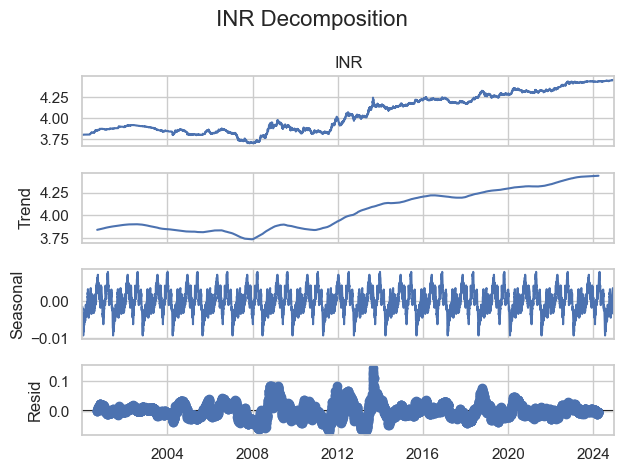

Decomposition for AUD


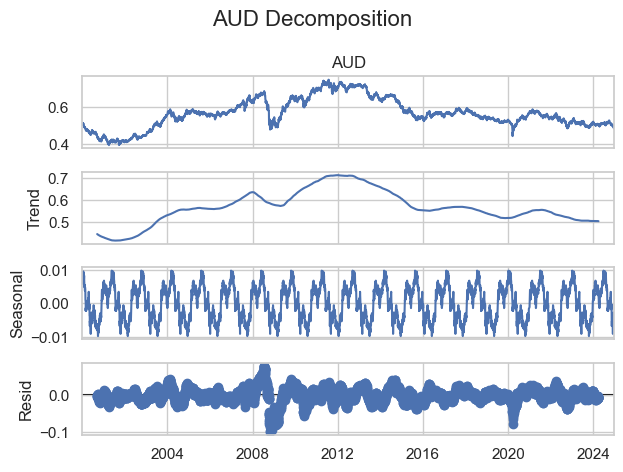

Decomposition for EUR


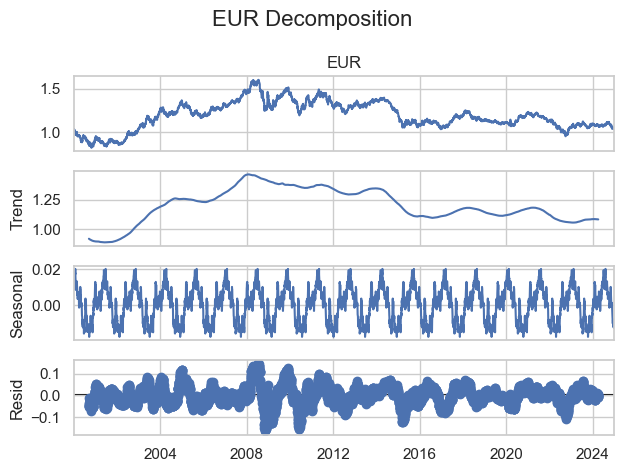

Decomposition for GBP


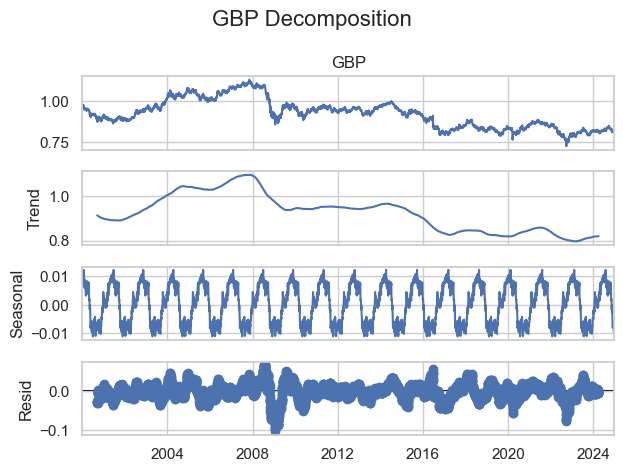

Decomposition for AED


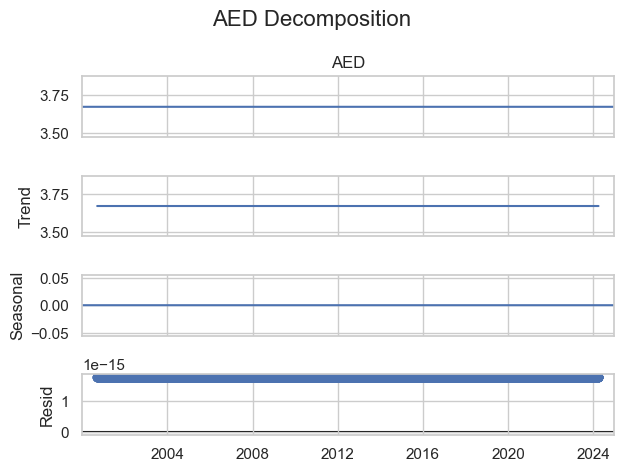

In [40]:
for currency in currencies:
    print(f"Decomposition for {currency}")
    series = df[currency].dropna()
    
    try:
        decomposition = seasonal_decompose(series, model='additive', period=365)
        decomposition.plot()
        plt.suptitle(f'{currency} Decomposition', fontsize=16)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not decompose {currency}: {e}")

In [43]:
df = df[currencies].diff().dropna()

We apply **first-order differencing** to remove trends and stabilize the mean. It transforms the data by subtracting the previous time step:

\[
Y_t' = Y_t - Y_{t-1}
\]

This operation:
- Removes linear trends,
- Helps make the series stationary,
- Preserves short-term dynamics essential for forecasting.

After differencing, we validate stationarity using the Augmented Dickey-Fuller (ADF) test. Once stationary, the series is ready for further preprocessing (e.g., normalization) and modeling.

In [44]:
for currency in currencies:
    if df[currency].nunique() == 1:
        print(f"{currency} is constant, skipping ADF test.")
        continue
    result = adfuller(df[currency])
    print(f'ADF Statistic for {currency}: {result[0]}')
    print(f'p-value for {currency}: {result[1]}')
    if result[1] <= 0.05:
        print(f'{currency} is stationary.')
    else:
        print(f'{currency} is non-stationary.')

ADF Statistic for INR: -13.363791554993437
p-value for INR: 5.363017381287827e-25
INR is stationary.
ADF Statistic for AUD: -82.57442605262227
p-value for AUD: 0.0
AUD is stationary.
ADF Statistic for EUR: -79.91369934851318
p-value for EUR: 0.0
EUR is stationary.
ADF Statistic for JPY: -45.599811229866695
p-value for JPY: 0.0
JPY is stationary.
ADF Statistic for GBP: -16.623864141720716
p-value for GBP: 1.688837657874076e-29
GBP is stationary.


### Feature Engineering

#### 1. Date features (year, month, day)

In [61]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

#### 2. Lag features (for lags 1, 7, 30)

In [62]:
for col in df.columns:
    for lag in [1, 7, 30]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

#### 3. Rolling mean (simple moving average)

In [63]:
window = 7  # or any window size you prefer
for col in df.columns:
    df[f'{col}_roll_mean_{window}'] = df[col].rolling(window=window).mean()
    df[f'{col}_roll_std_{window}'] = df[col].rolling(window=window).std()

#### 4. Exponential Moving Average (EMA)

In [65]:
span = 7  # window size for EMA
ema_features = []

# Calculate EMA columns and store in a list
for col in df.columns:
    ema_col = df[col].ewm(span=span, adjust=False).mean()
    ema_col.name = f'{col}_ema_{span}'
    ema_features.append(ema_col)

# Concatenate all new EMA columns at once
df = pd.concat([df] + ema_features, axis=1)

# Optional: defragment memory
df = df.copy()

### Feature Scaling

In [71]:
scaler = StandardScaler()
df[:] = scaler.fit_transform(df)

# Check the result
df.describe()

,INR,AUD,EUR,JPY,GBP,year,month,day,INR_lag_1,INR_lag_7,...,month_lag_7_roll_mean_7_ema_7_ema_7,month_lag_7_roll_std_7_ema_7_ema_7,month_lag_30_roll_mean_7_ema_7_ema_7,month_lag_30_roll_std_7_ema_7_ema_7,day_lag_1_roll_mean_7_ema_7_ema_7,day_lag_1_roll_std_7_ema_7_ema_7,day_lag_7_roll_mean_7_ema_7_ema_7,day_lag_7_roll_std_7_ema_7_ema_7,day_lag_30_roll_mean_7_ema_7_ema_7,day_lag_30_roll_std_7_ema_7_ema_7
count,6.321000e+03,6321.000000,6.321000e+03,6.321000e+03,6.321000e+03,6.321000e+03,6.321000e+03,6.321000e+03,6.320000e+03,6.314000e+03,...,6.308000e+03,6.308000e+03,6.285000e+03,6.285000e+03,6.314000e+03,6.314000e+03,6.308000e+03,6.308000e+03,6.285000e+03,6.285000e+03
mean,-3.372296e-18,0.000000,-7.868690e-18,-1.348918e-17,-1.124099e-17,-5.323731e-15,-1.641184e-16,4.187267e-17,-4.497106e-18,6.752069e-18,...,9.011322e-18,-2.590755e-17,1.322729e-16,3.165505e-17,-5.289121e-16,-1.237879e-16,2.117661e-16,8.177775e-16,-2.724595e-16,1.401866e-16
std,1.000079e+00,1.000079,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00,...,1.000079e+00,1.000079e+00,1.000080e+00,1.000080e+00,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00,1.000080e+00,1.000080e+00
min,-7.892024e+00,-13.089109,-9.530677e+00,-8.399068e+00,-1.372939e+01,-1.641867e+00,-1.606535e+00,-1.680880e+00,-7.891416e+00,-7.887753e+00,...,-1.713581e+00,-5.370526e-01,-1.711451e+00,-5.367320e-01,-2.662267e+00,-1.569346e+00,-2.664734e+00,-1.568912e+00,-2.662717e+00,-1.567776e+00
25%,-3.551349e-01,-0.506985,-5.222882e-01,-4.654891e-01,-5.357894e-01,-8.095992e-01,-7.280830e-01,-8.794632e-01,-3.552368e-01,-3.555990e-01,...,-8.410186e-01,-4.123080e-01,-8.374815e-01,-4.122008e-01,-8.812960e-01,-9.176186e-01,-8.772446e-01,-9.176781e-01,-8.799043e-01,-9.167187e-01
50%,-2.788777e-02,0.000946,-6.757765e-04,-9.897386e-03,7.014271e-03,2.266869e-02,-1.424480e-01,3.644205e-02,-2.789819e-02,-2.780642e-02,...,-8.332886e-03,-2.447379e-01,-3.182693e-02,-2.449174e-01,-1.215659e-01,-1.195690e-01,-1.228593e-01,-1.196846e-01,-1.229937e-01,-1.216251e-01
75%,3.437106e-01,0.558022,5.209367e-01,4.928245e-01,5.589333e-01,8.549365e-01,7.360045e-01,8.378592e-01,3.437293e-01,3.437691e-01,...,8.251671e-01,-1.215224e-02,8.163558e-01,-1.276239e-02,8.948618e-01,8.852113e-01,8.953210e-01,8.849575e-01,8.951383e-01,8.858662e-01
max,1.054894e+01,8.652259,7.851707e+00,6.274126e+00,6.777286e+00,1.687204e+00,1.614457e+00,1.753764e+00,1.054810e+01,1.054339e+01,...,1.725544e+00,6.132782e+00,1.733599e+00,6.121698e+00,2.050568e+00,2.017755e+00,2.050146e+00,2.016830e+00,2.047486e+00,2.017987e+00


In [75]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values

INR_lag_1                              1
INR_lag_7                              7
INR_lag_30                            30
AUD_lag_1                              1
AUD_lag_7                              7
                                      ..
day_lag_1_roll_std_7_ema_7_ema_7       7
day_lag_7_roll_mean_7_ema_7_ema_7     13
day_lag_7_roll_std_7_ema_7_ema_7      13
day_lag_30_roll_mean_7_ema_7_ema_7    36
day_lag_30_roll_std_7_ema_7_ema_7     36
Length: 352, dtype: int64

## Final dataset

In [72]:
model_data = df.copy()

In [74]:
# Define the path to save the CSV file
repo_path = r"C:\Users\shiri\OneDrive\Documents\Python\ml-projects\exchange-rates-forecasting"
save_path = os.path.join(repo_path, "data", "processed")

# Ensure the directory exists
os.makedirs(save_path, exist_ok=True)

# Save the dataset as a CSV file
csv_file_path = os.path.join(save_path, "model_data.csv")
model_data.to_csv(csv_file_path, index=True)

print(f"Dataset saved successfully at: {csv_file_path}")

Dataset saved successfully at: C:\Users\shiri\OneDrive\Documents\Python\ml-projects\exchange-rates-forecasting\data\processed\model_data.csv
